<a href="https://colab.research.google.com/github/xtianu/CV_Tirana_2026/blob/main/M3_Image%20Classification/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MODULE 3: IMAGE CLASSIFICATION

Christian Mata, PhD


# **EXERCISE 4**

#1. Generate synthetic image with random blobs

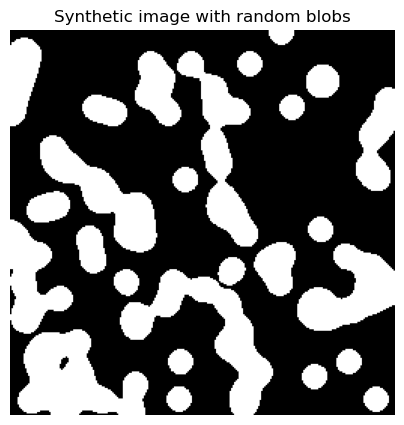

In [4]:
from skimage.data import binary_blobs
import matplotlib.pyplot as plt

I = binary_blobs(
    length=256,
    blob_size_fraction=0.1,
    volume_fraction=0.35
)

plt.figure(figsize=(5, 5))
plt.imshow(I, cmap="gray")
plt.title("Synthetic image with random blobs")
plt.axis("off")
plt.show()

# 2. Object segmentation and labeling

- Segmentation of blobs using Otsu's optimal threshold
- Labeling connected regions
- Visualization

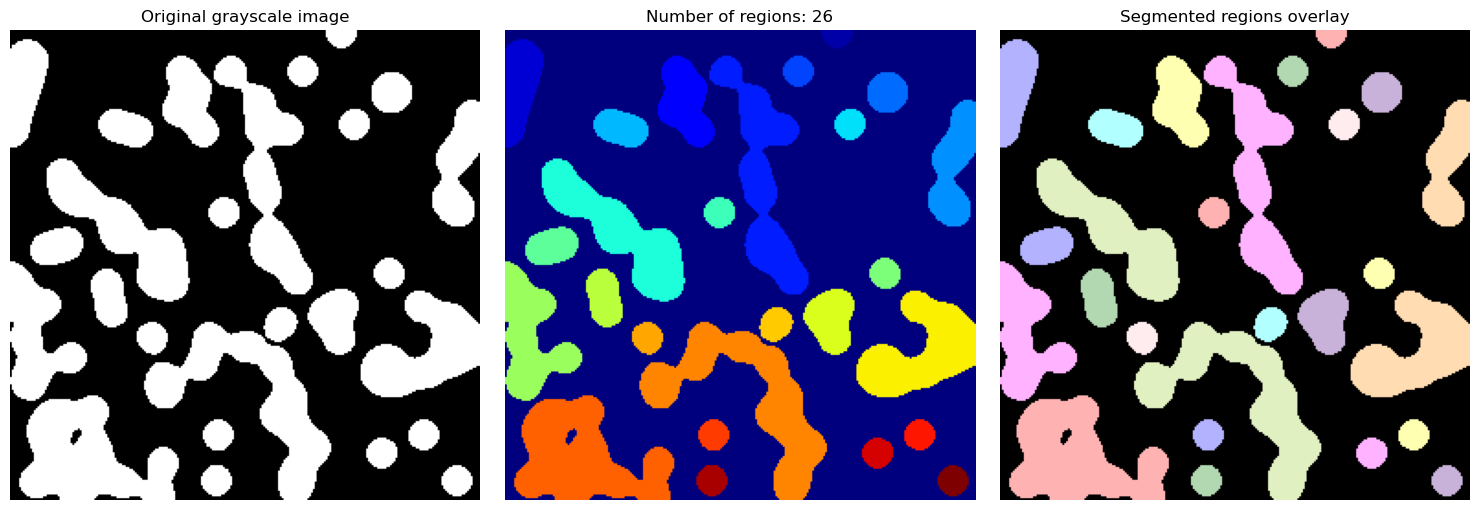

In [7]:
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.color import label2rgb

#Otsu Threeshold
threshold = threshold_otsu(I)
I_segmented = I > threshold

#Lbael connected components
label_image = label(I_segmented)

#Count Regions
props = regionprops(label_image)
no_regions = len(props)

#Segmented regions overlay
overlay = label2rgb(label_image, image=I, bg_label=0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(I, cmap="gray")
ax[0].set_title("Original grayscale image")
ax[0].axis("off")

ax[1].imshow(label_image, cmap=plt.cm.jet)
ax[1].set_title(f"Number of regions: {no_regions}")
ax[1].axis("off")

ax[2].imshow(overlay)
ax[2].set_title("Segmented regions overlay")
ax[2].axis("off")

plt.tight_layout()
plt.show()

# 3. Get regional properties in a pandas dataframe

Function documentation with a list of available attributes can be found at https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops_table


In [9]:
from skimage.measure import regionprops
import pandas as pd

props = regionprops(label_image)

data = []

for region in props:
    data.append({
        "label": region.label,
        "area": region.area,
        "eccentricity": region.eccentricity,
        "extent": region.extent,
        "axis_major_length": region.major_axis_length
    })

df = pd.DataFrame(data)

df.head()

,label,area,eccentricity,extent,axis_major_length
0,1,136.0,0.795939,0.800000,17.334087
1,2,891.0,0.948417,0.719128,61.932589
2,3,1013.0,0.862393,0.653548,52.062765
3,4,2482.0,0.975879,0.353561,151.460036
4,5,221.0,0.000000,0.764706,16.768857


Represent area of the blobs as a function of the major axis length

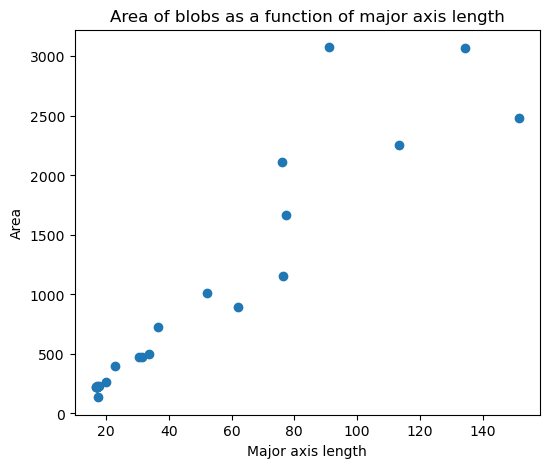

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.scatter(df["axis_major_length"], df["area"])

plt.xlabel("Major axis length")
plt.ylabel("Area")
plt.title("Area of blobs as a function of major axis length")

plt.show()

Clear correlation between blob's length and area can be observed

#4. Analyze blobs


Since you have the feature data in a pandas dataframe, you can exploit all the functions of te libraries. For instance:

How many blobs have an area above the average?

In [ ]:
average_area = df["area"].mean()

blobs_above_average = df[df["area"] > average_area]

number_above_average = len(blobs_above_average)

print("Average area:", average_area)
print("Number of blobs with area above average:", number_above_average)

Average area: 882.2307692307693
Number of blobs with area above average: 9


Represent the blobs that have an area smaller than the average blob's area

There are 17 blobs with area smaller than average 882.2307692307693.`


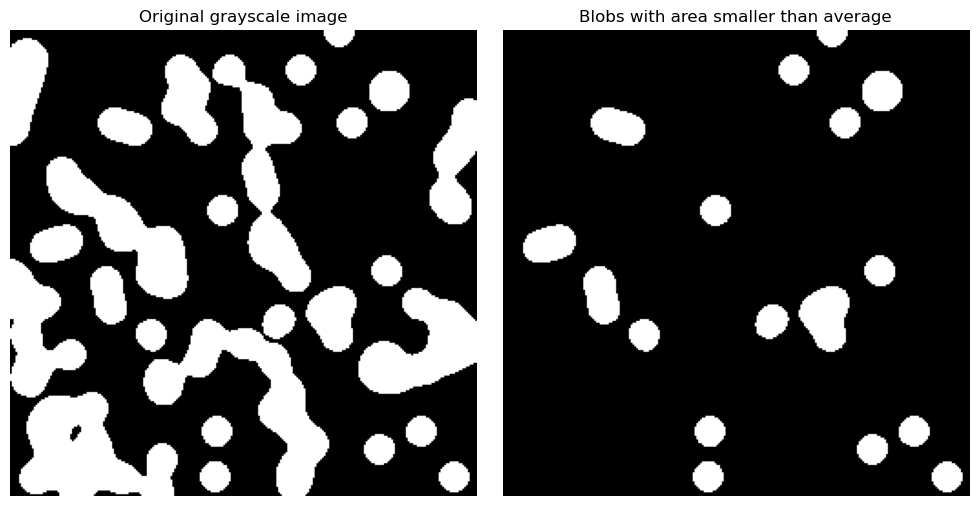

In [ ]:
import numpy as np

#labels of blobs smaller than average
small_blob_labels = df[df["area"] < average_area]["label"]

print("There are {} blobs with area smaller than average {}.`".format(len(small_blob_labels) , average_area))


Find the labels of small and large blobs

In [17]:
large_blob_labels = df[df["area"] > average_area]["label"]

print("Average area:", average_area)

print("Small blob labels:")
print(small_blob_labels.values)

print("Large blob labels:")
print(large_blob_labels.values)

Average area: 882.2307692307693
Small blob labels:
[ 1  5  6  8  9 11 12 13 15 16 18 19 22 23 24 25 26]
Large blob labels:
[ 2  3  4  7 10 14 17 20 21]


Create a binary mask with the large and small blobs

In [22]:
small_blob_mask = np.zeros(label_image.shape, dtype=bool)
large_blob_mask = np.zeros(label_image.shape, dtype=bool)

#small blob mask
for lab in small_blob_labels:
    small_blob_mask[label_image == lab] = True

#large blob mask
for lab in large_blob_labels:
    large_blob_mask[label_image == lab] = True

Represent the large and small blobs

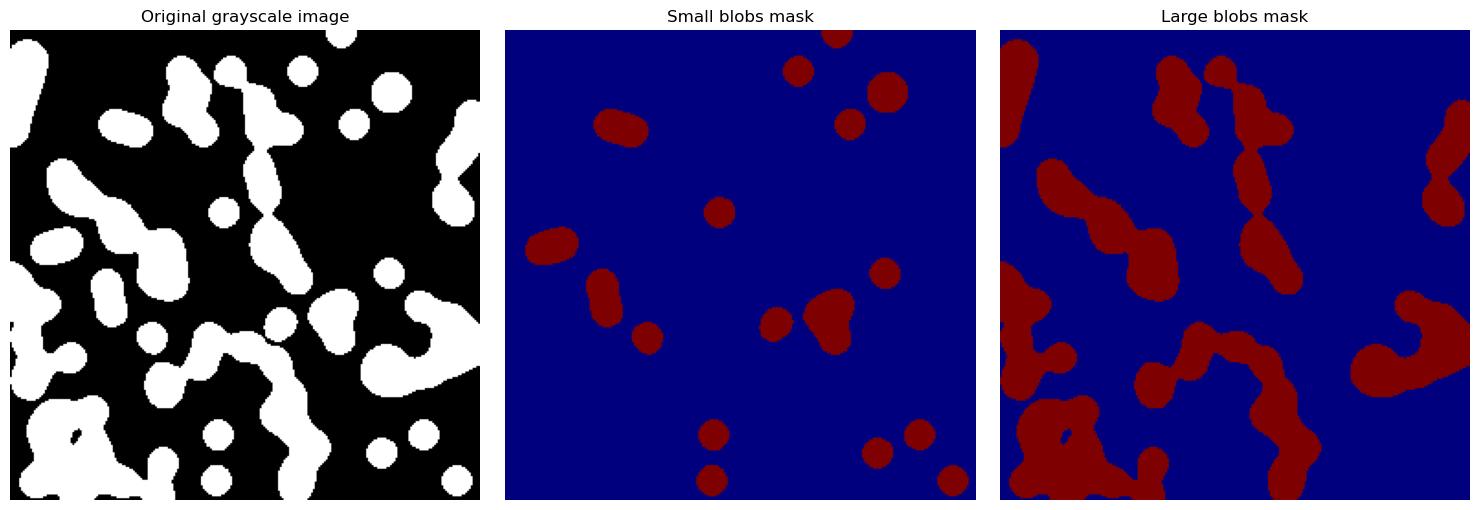

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(I, cmap="gray")
ax[0].set_title("Original grayscale image")
ax[0].axis("off")


ax[1].imshow(small_blob_mask, cmap=plt.cm.jet)
ax[1].set_title("Small blobs mask")
ax[1].axis("off")

ax[2].imshow(large_blob_mask, cmap=plt.cm.jet)
ax[2].set_title("Large blobs mask")
ax[2].axis("off")

plt.tight_layout()
plt.show()

#5. Obtain texture-based regional properties

For the original image

In [26]:
# 5. Obtain texture-based regional properties
from skimage.feature import graycomatrix, graycoprops
from skimage import img_as_ubyte

I_texture = img_as_ubyte(I_segmented)

I_texture[I_texture > 0] = 1

# gray-level co-occurrence matrix
g = graycomatrix(
    I_texture,
    distances=[1],
    angles=[0],
    levels=2,
    symmetric=False,
    normed=False
)

print(g[:, :, 0, 0])

print("Number of times that grayscale level 0 has a neighbour with value 0 at distance 1 to the right:", g[0, 0, 0, 0])
print("Number of times that grayscale level 0 has a neighbour with value 1 at distance 1 to the right:", g[0, 1, 0, 0])
print("Number of times that grayscale level 1 has a neighbour with value 0 at distance 1 to the right:", g[1, 0, 0, 0])
print("Number of times that grayscale level 1 has a neighbour with value 1 at distance 1 to the right:", g[1, 1, 0, 0])

[[41397   996]
 [ 1042 21845]]
Number of times that grayscale level 0 has a neighbour with value 0 at distance 1 to the right: 41397
Number of times that grayscale level 0 has a neighbour with value 1 at distance 1 to the right: 996
Number of times that grayscale level 1 has a neighbour with value 0 at distance 1 to the right: 1042
Number of times that grayscale level 1 has a neighbour with value 1 at distance 1 to the right: 21845


In [27]:
I_texture = img_as_ubyte(I)

texture_data = []

for region in props:
  
    mask = label_image == region.label
    
    minr, minc, maxr, maxc = region.bbox
    
    # crop image and mask around the region
    region_image = I_texture[minr:maxr, minc:maxc]
    region_mask = mask[minr:maxr, minc:maxc]
    
    # keep only region pixels, background becomes 0
    region_image = region_image * region_mask
    
    # gray-level co-occurrence matrix
    g = graycomatrix(
        region_image,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=False,
        normed=True
    )
    
    texture_data.append({
        "label": region.label,
        "Contrast": graycoprops(g, "contrast")[0, 0],
        "Dissimilarity": graycoprops(g, "dissimilarity")[0, 0],
        "Homogeneity": graycoprops(g, "homogeneity")[0, 0],
        "Energy": graycoprops(g, "energy")[0, 0],
        "Correlation": graycoprops(g, "correlation")[0, 0]
    })

texture_df = pd.DataFrame(texture_data)

texture_df

,label,Contrast,Dissimilarity,Homogeneity,Energy,Correlation
0,1,4876.875000,19.125000,0.925001,0.801171,0.740260
1,2,3085.932203,12.101695,0.952543,0.748509,0.884467
2,3,3814.800000,14.960000,0.941334,0.709568,0.867061
3,4,2340.522496,9.178520,0.964006,0.710535,0.921827
4,5,5737.500000,22.500000,0.911766,0.769780,0.730159
5,6,3800.162338,14.902597,0.941559,0.824849,0.779161
6,7,3807.260870,14.930435,0.941450,0.702806,0.870453
7,8,3309.975369,12.980296,0.949098,0.771339,0.857314
8,9,5498.437500,21.562500,0.915442,0.784614,0.724603
9,10,1580.694306,6.198801,0.975691,0.712428,0.948142


Comment:

Texture features describe how pixel intensities are arranged inside each labelled blob.
`Contrast` and `dissimilarity` measure intensity variation, while `homogeneity` and `energy` are higher when the texture is more uniform. `Correlation` measures how related neighboring pixel values are. Since these blobs are binary/simple shapes, the texture values mainly describe how smooth or irregular each blob region is.
